In [1]:
import joblib
import pandas as pd
import missingno as msno 
from sklearn.preprocessing import MinMaxScaler

In [3]:
path = 'datasets/mega_dataset.csv'
df = pd.read_csv(path, parse_dates=['Date'])
df.head()

,Date,Gold_Price,Crude_Oil,Inflation,Interest_Rate,USD_EUR,SLV,^GSPC,sent_enc,increase_ind
0,2023-01-03,0.279186,0.614588,0.722545,0.810606,0.351997,0.528008,0.411833,2,0
1,2023-01-04,0.292612,0.614588,0.722545,0.810606,0.374767,0.520214,0.419316,2,1
2,2023-01-05,0.274683,0.614588,0.722545,0.810606,0.338186,0.495860,0.407670,2,-1
3,2023-01-06,0.301284,0.614588,0.722545,0.810606,0.374393,0.521676,0.430246,2,1
4,2023-01-09,0.304536,0.614588,0.722545,0.810606,0.426652,0.512908,0.429469,0,1


<Axes: >

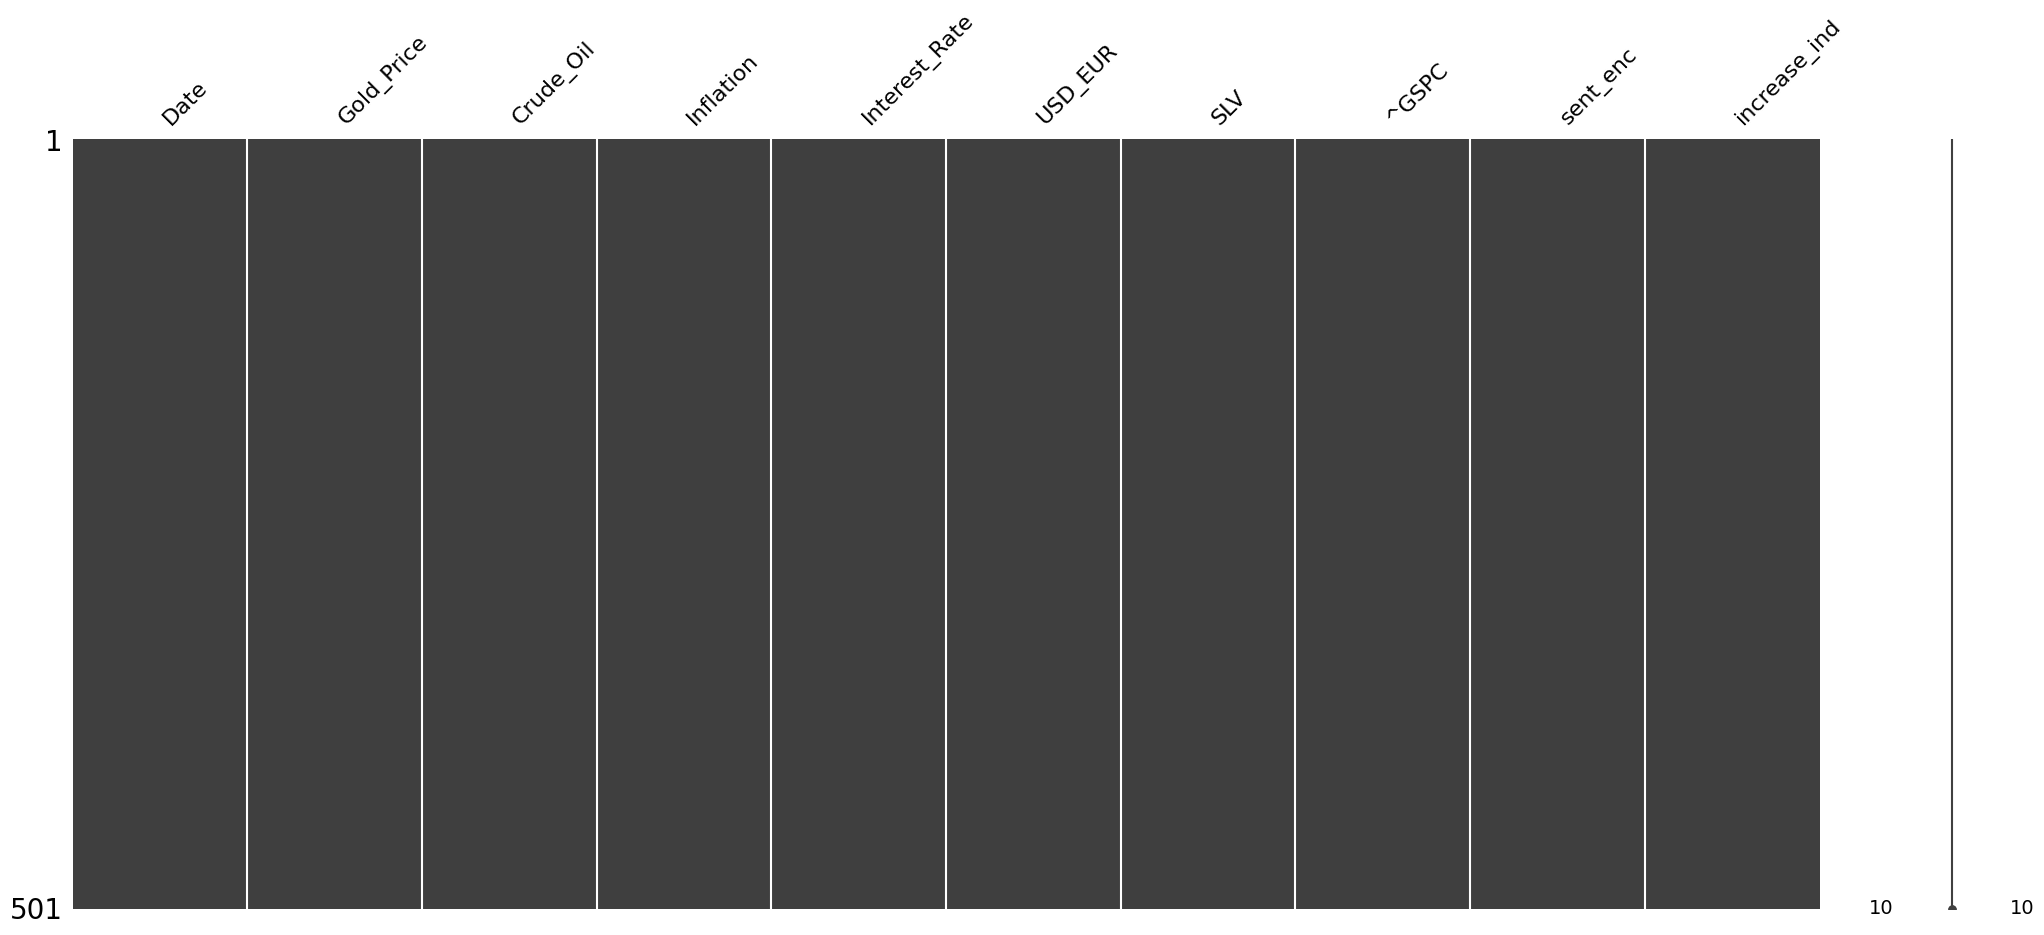

In [7]:
msno.matrix(df)

In [8]:
df.isnull().sum()

Date             0
Gold_Price       0
Crude_Oil        0
Inflation        0
Interest_Rate    0
USD_EUR          0
SLV              0
^GSPC            0
sent_enc         0
increase_ind     0
dtype: int64

In [11]:
not_feat = ['Date', 'Gold_Price', 'sent_enc', 'increase_ind']
features = [col for col in df.columns if col not in not_feat]
target = 'Gold_Price'

feat_scaler = MinMaxScaler()
targ_scaler = MinMaxScaler()

df[features] = feat_scaler.fit_transform(df[features])
df[target] = targ_scaler.fit_transform(df[[target]])

df.head()

,Date,Gold_Price,Crude_Oil,Inflation,Interest_Rate,USD_EUR,SLV,^GSPC,sent_enc,increase_ind
0,2023-01-03,0.030398,0.435045,0.0,0.0,0.234763,0.273613,0.007028,2,0
1,2023-01-04,0.048458,0.435045,0.0,0.0,0.303612,0.261619,0.019661,2,1
2,2023-01-05,0.024341,0.435045,0.0,0.0,0.193002,0.224138,0.000000,2,-1
3,2023-01-06,0.060123,0.435045,0.0,0.0,0.302483,0.263868,0.038113,2,1
4,2023-01-09,0.064498,0.435045,0.0,0.0,0.460497,0.250375,0.036803,0,1


In [12]:
joblib.dump(feat_scaler, 'scalers/feat_scaler.pkl')
joblib.dump(targ_scaler, 'scalers/target_scaler.pkl')

['scalers/target_scaler.pkl']

In [13]:
path = 'datasets/mega_dataset_scaled.csv'
df.to_csv(path, index=False)